In [29]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit import cost
from scipy import stats
from sympy import * 
import pandas as pd
r = np.random 
r.seed(42)

## 5.1

### 5.1.1

In [30]:
dataframe = pd.read_csv('Data/data_RunningTimes.csv', header=0)
dist, t, sigma_t = dataframe.values.T

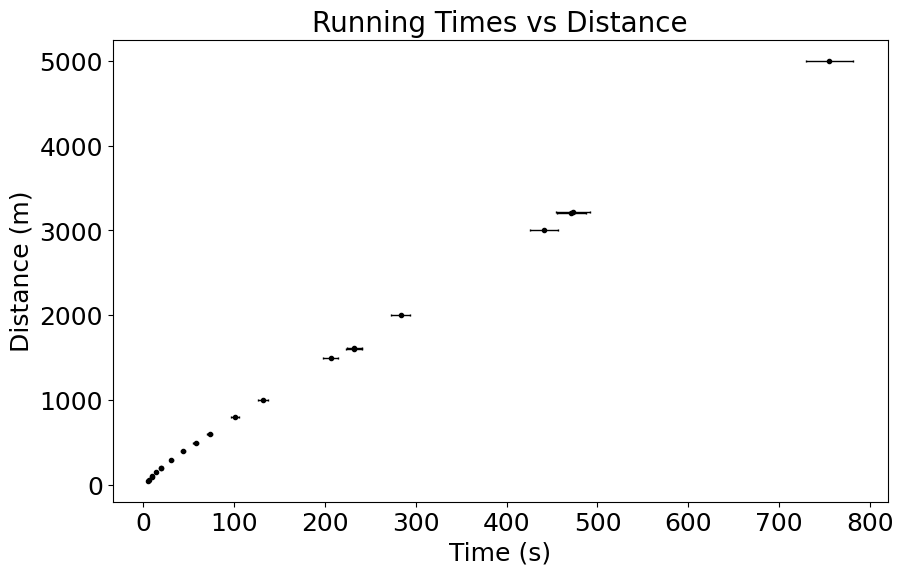

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(t, dist, yerr=0, xerr=sigma_t, label='Data, with errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
ax.set_xlabel(r'Time (s)', fontsize=18)
ax.set_ylabel(r'Distance (m)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_title('Running Times vs Distance', fontsize=20);

In [32]:
def velocity_func(t, v):
    return t * v

In [33]:
sd = np.ones_like(dist)

for i in range(10):
    sd_old = sd.copy()
    cfit = cost.LeastSquares(t, dist, sd_old, velocity_func)
    mfit = Minuit(cfit, v=5)
    mfit.migrad()
    print(mfit.fval)
    print(f'velocity = {mfit.values[0]:.2f} +/- {mfit.errors[0]:.2f} m/s')
    v = mfit.values[0]
    sd = v * sigma_t
    if np.allclose(sd, sd_old):
        break

116452.11062168535
velocity = 6.80 +/- 0.00 m/s
365.7060388201267
velocity = 7.79 +/- 0.07 m/s
278.8435977918222
velocity = 7.79 +/- 0.08 m/s


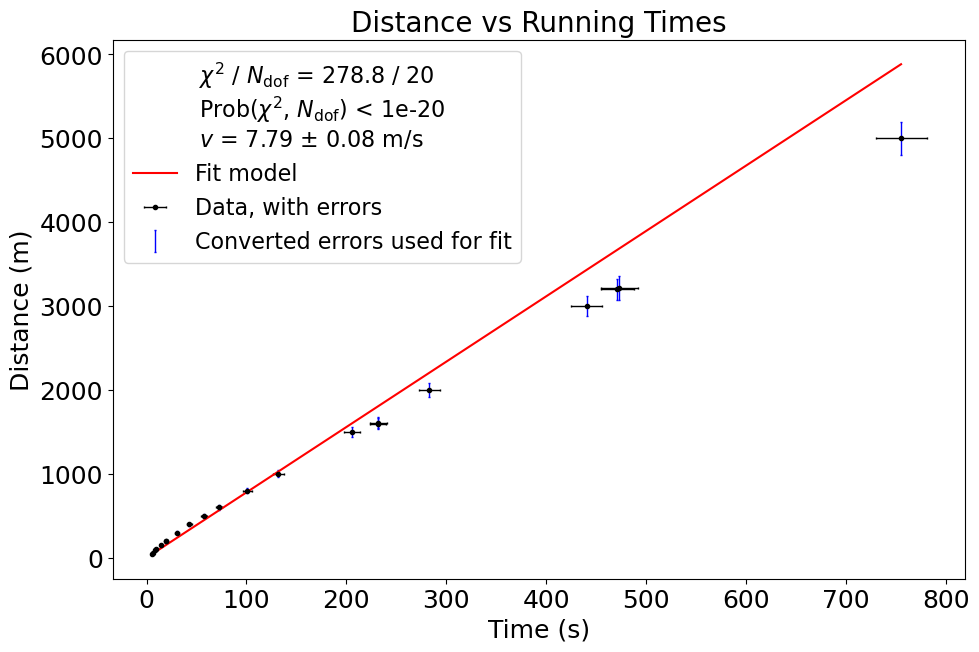

In [34]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.errorbar(t, dist, xerr=sigma_t, label='Data, with errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
ax.errorbar(t, dist, yerr=sd, label='Converted errors used for fit', fmt='none',  ecolor='b', elinewidth=1, capsize=1, capthick=1)
ax.set_xlabel(r'Time (s)', fontsize=18)
ax.set_ylabel(r'Distance (m)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_title('Distance vs Running Times', fontsize=20)
xx = np.linspace(min(t), max(t), 1000)
ax.plot(xx, velocity_func(xx, *mfit.values[:]), '-r', label='Fit model')

chi2 = mfit.fval 
Ndof = len(t) - mfit.nfit
Prob = stats.chi2.sf(chi2, Ndof)

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) < {10**(-20)}",]
fit_info.append(fr"$v$ = {mfit.values[0]:.2f} $\pm$ {mfit.errors[0]:.2f} m/s")

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');

### 5.1.2

In [35]:
def power_func(x, a, b):
    return b*x**a
def exp_func(x, a, b):
    return b*a**x
def lin_func(x, a, b):
    return a*x + b
def poly2(x, a, b, c):
    return a*x**2 + b*x + c

In [36]:
cfit = cost.LeastSquares(dist, t, sigma_t, exp_func)
mfit = Minuit(cfit, a=1, b=1)
mfit.migrad()
chi2=mfit.fval
ndof = len(t)- mfit.nfit 
prob = stats.chi2.sf(chi2, ndof)
print(f'Exponential Fit: chi2/ndof = {chi2:.2f}/{ndof}, Prob = {prob:.20f}')

cfit = cost.LeastSquares(dist, t, sigma_t, lin_func)
mfit = Minuit(cfit, a=1, b=1)
mfit.migrad()
chi2=mfit.fval
ndof = len(t)- mfit.nfit 
prob = stats.chi2.sf(chi2, ndof)
print(f'Linear Fit: chi2/ndof = {chi2:.2f}/{ndof}, Prob = {prob:.20f}')

cfit = cost.LeastSquares(dist, t, sigma_t, poly2)
mfit = Minuit(cfit, a=1, b=1, c=1)
mfit.migrad();
chi2=mfit.fval
ndof = len(t)- mfit.nfit 
prob = stats.chi2.sf(chi2, ndof)
print(f'Quadratic Fit: chi2/ndof = {chi2:.2f}/{ndof}, Prob = {prob:.6f}')

Exponential Fit: chi2/ndof = 4762.26/19, Prob = 0.00000000000000000000
Linear Fit: chi2/ndof = 149.48/19, Prob = 0.00000000000000000000
Quadratic Fit: chi2/ndof = 61.32/18, Prob = 0.000001


In [37]:
cfit = cost.LeastSquares(dist, t, sigma_t, power_func)
mfit = Minuit(cfit, a=1, b=1)
mfit.migrad();

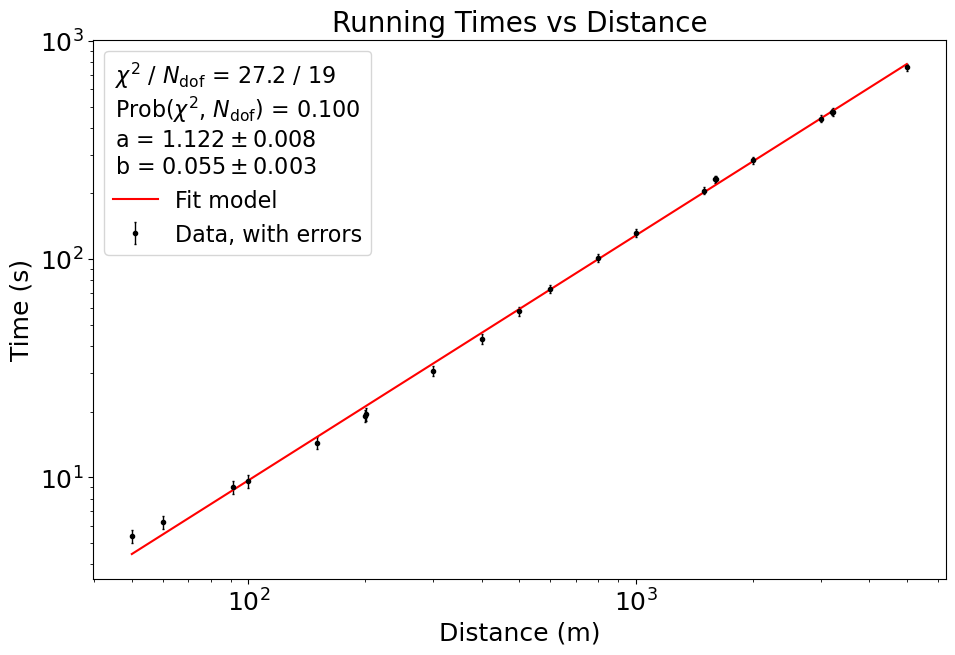

In [38]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.errorbar(dist, t, yerr=sigma_t, label='Data, with errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
ax.set_xlabel(r'Distance (m)', fontsize=18)
ax.set_ylabel(r'Time (s)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_title('Running Times vs Distance', fontsize=20)
ax.set_xscale('log')
ax.set_yscale('log')
xx = np.linspace(min(dist), max(dist), 1000)
ax.plot(xx, power_func(xx, *mfit.values[:]), '-r', label='Fit model')
# Adding fit results to plot:
chi2 = mfit.fval 
Ndof = len(dist) - mfit.nfit 
Prob = stats.chi2.sf(chi2, Ndof) 

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]
for p, v, e in zip(mfit.parameters, mfit.values[:], mfit.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');

[  91.4  600.   800.  1000.  1500.  2000. ]


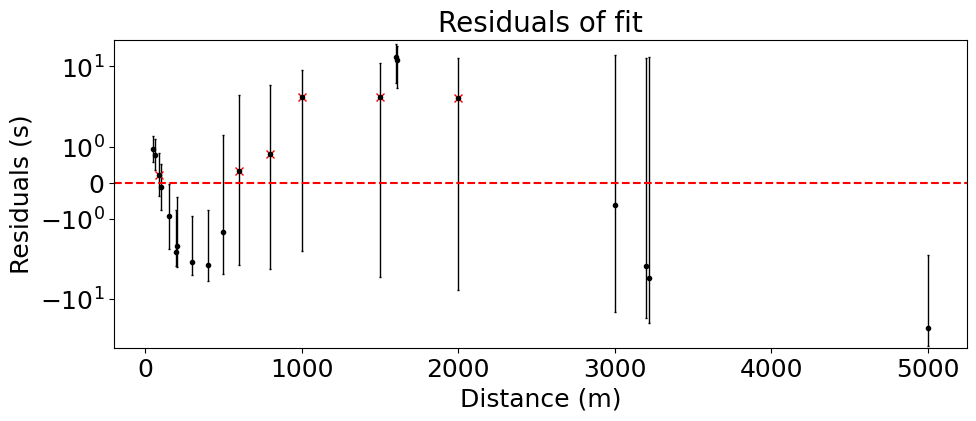

In [39]:
residuals = t - power_func(dist, *mfit.values[:])
fig, ax = plt.subplots(figsize=(11, 4))
ax.errorbar(dist, residuals, yerr=sigma_t, fmt='.k', ecolor='k', elinewidth=1, capsize=1, capthick=1)
mask = (residuals > 0) & (residuals-sigma_t < 0)
print(dist[mask])
ax.plot(dist[mask], residuals[mask], 'xr')
ax.axhline(0, color='r', linestyle='--')
ax.set_xlabel(r'Distance (m)', fontsize=18)
ax.set_ylabel('Residuals (s)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_title('Residuals of fit', fontsize=20);
ax.set_yscale('symlog')

[50.] [0.94433031] [2.55224409]
[  60.  1600.  1609.3] [ 0.78252476 13.90419319 12.78193828] [1.81982502 1.67117707 1.55687433]


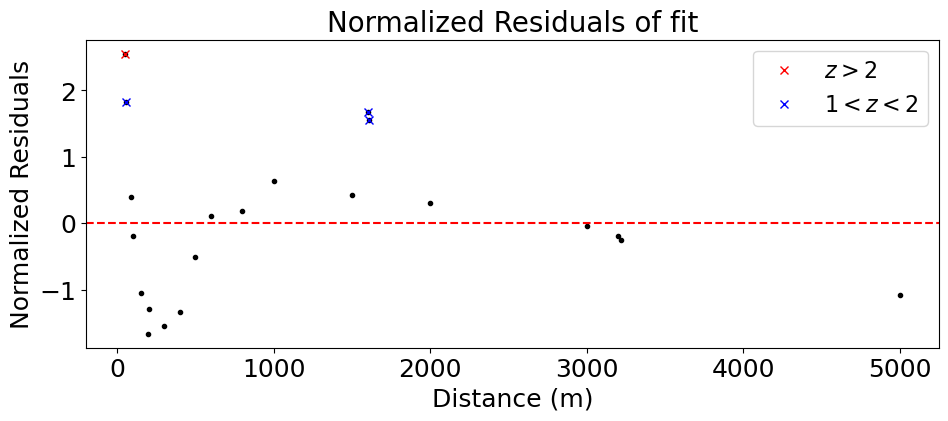

In [40]:
zvals = (residuals) / sigma_t
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(dist, zvals, '.k')
ax.axhline(0, color='r', linestyle='--')

mask2 = (zvals >2)
print(dist[mask2], residuals[mask2], zvals[mask2])
ax.plot(dist[mask2], zvals[mask2], 'xr', label=r'$z>2$')

mask1 = (zvals > 1) & (zvals < 2)
print(dist[mask1], residuals[mask1], zvals[mask1])
ax.plot(dist[mask1], zvals[mask1], 'xb', label=r'$1 < z < 2$')

# mask0 = (zvals >0) & (zvals < 1)
# print(dist[mask0], zvals[mask0])
# ax.plot(dist[mask0], zvals[mask0], 'xg')

ax.set_xlabel(r'Distance (m)', fontsize=18)
ax.set_ylabel('Normalized Residuals', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_title('Normalized Residuals of fit', fontsize=20)
ax.legend(fontsize=16);

## 5.2

### 5.2.1

In [41]:
dataframe = pd.read_csv('Data/data_RadioSignals.csv', header=0)
freq, D, E = dataframe.values.T
for i in range(10):
    print(f"  Frequency: {freq[i]:7.4f}      D: {D[i]:6.4f}      E: {E[i]:6.4f}")

  Frequency: 12.0157      D: 2.3299      E: 2.6552
  Frequency: 12.4582      D: 1.5141      E: -0.3078
  Frequency: 12.7235      D: 3.6396      E: 6.2029
  Frequency: 12.1906      D: 3.1901      E: 5.7257
  Frequency: 12.6308      D: 0.7336      E: -0.8379
  Frequency: 12.0860      D: 3.9196      E: 1.3004
  Frequency: 12.2640      D: 4.5627      E: 3.3668
  Frequency: 12.3738      D: 2.8879      E: 5.0982
  Frequency: 12.0638      D: 3.3318      E: 1.3044
  Frequency: 12.1573      D: 2.2051      E: 5.3526


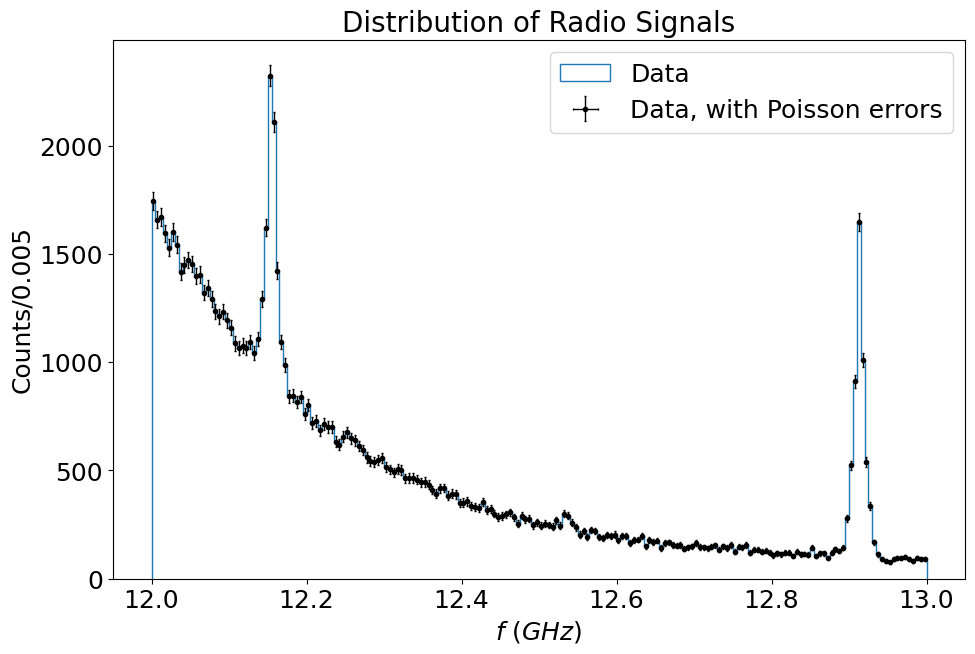

In [42]:
xmin = 12
xmax = 13
Nbins = 200
binwidth = (xmax - xmin) / Nbins

fig, ax = plt.subplots(figsize=(11, 7))
ax.hist(freq, bins=Nbins, range=(xmin, xmax), histtype='step', label='Data')
counts, bin_edges = np.histogram(freq, bins=Nbins, range=(xmin, xmax))
x = (bin_edges[1:] + bin_edges[:-1])/2
y = counts    
sy = np.sqrt(counts) 
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

ax.set_xlabel(r'$f$ $(GHz)$', fontsize=18)
ax.set_ylabel(f'Counts/{binwidth:.3f}', fontsize=18)
ax.set_title('Distribution of Radio Signals', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18);

In [43]:
def exp_pdf(x, x0, Nexp, tau):
    return Nexp*1.0 / tau * np.exp(-((x-x0)/tau))*binwidth

def fit_pdf(x, x0, Ngauss, mu, sigma, Nexp, tau):
    gauss = stats.norm.pdf(x, mu, sigma)
    exp = 1/tau * np.exp(-(x-x0) / tau)
    return (Ngauss * gauss + Nexp * exp) * binwidth

def fit_llh(x, x0, Ngauss, mu, sigma, Nexp, tau):
    gauss = stats.norm.pdf(x, mu, sigma)
    exp = 1/tau * np.exp(-(x-x0) / tau)
    return Ngauss + Nexp, Ngauss*gauss + Nexp * exp

#### Test

#### Real fit

In [44]:
mask1 = (x>12) & (x<12.4)
cfit1 = cost.LeastSquares(x[mask1], y[mask1], sy[mask1], fit_pdf)
mfit1 = Minuit(cfit1, x0=13, Ngauss=2500, mu=12.155, sigma=0.003, Nexp=4000, tau=0.27)
mfit1.limits['Ngauss'] = (0, 5000)
mfit1.limits['mu'] = (12.1, 12.2)
mfit1.limits['Nexp'] = (0, 10000)
mfit1.migrad();

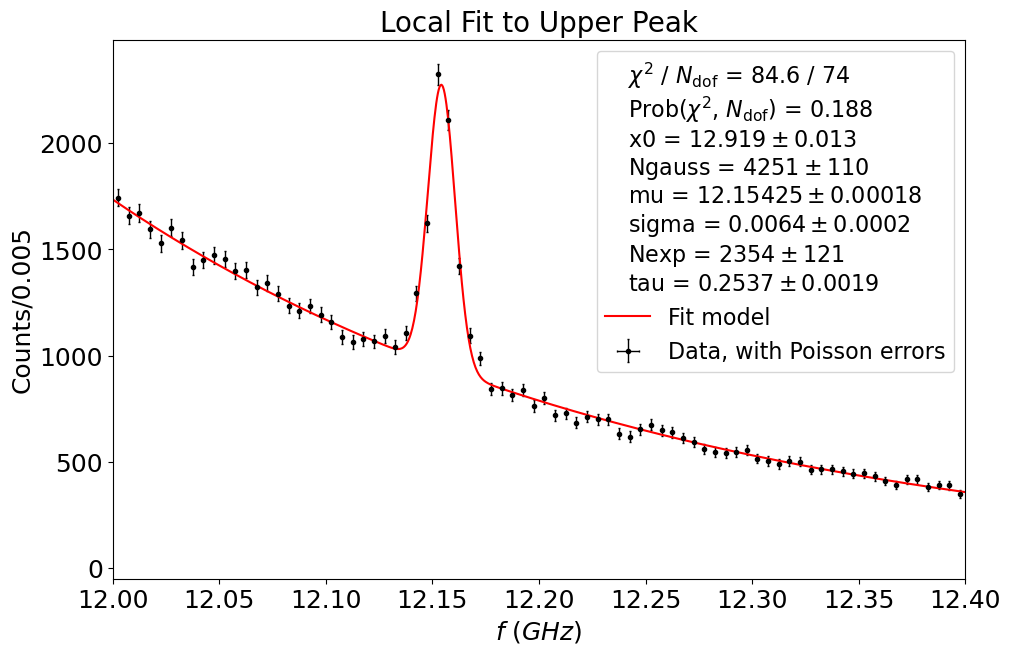

In [45]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

xx = np.linspace(12.0, 12.4, 1000)
ax.plot(xx, fit_pdf(xx, *mfit1.values[:]), '-r', label='Fit model')

ax.set_xlabel(r'$f$ $(GHz)$', fontsize=18)
ax.set_ylabel(f'Counts/{binwidth:.3f}', fontsize=18)
ax.set_title('Local Fit to Upper Peak', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18)
ax.set_xlim(12, 12.4)

# Adding fit results to plot:
chi2 = mfit1.fval 
Ndof = len(x[mask1]) - mfit1.nfit 
Prob = stats.chi2.sf(chi2, Ndof) 

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]
for p, v, e in zip(mfit1.parameters, mfit1.values[:], mfit1.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');

In [46]:
mask2 = (x>12.6) & (x<13)
cfit2 = cost.LeastSquares(x[mask2], y[mask2], sy[mask2], fit_pdf)
mfit2 = Minuit(cfit2, x0=13, Ngauss=5000, mu=12.912, sigma=0.01, Nexp=4000, tau=0.27)
mfit2.limits['Ngauss'] = (2000, 6000)
mfit2.limits['mu'] = (12.85, 12.95)
mfit2.limits['sigma'] = (0, 0.02)
mfit2.migrad();

In [47]:
xmin = 12
xmax = 13
Nbins = 200
binwidth = (xmax - xmin) / Nbins
counts, bin_edges = np.histogram(freq, bins=Nbins, range=(xmin, xmax))
x = (bin_edges[1:] + bin_edges[:-1])/2
y = counts    
sy = np.sqrt(counts) 

In [48]:
def fit_pdf2(x, x0, Ncauchy, mu, sigma, Nexp, tau):
    cauchy = stats.cauchy.pdf(x, mu, sigma)
    exp = 1/tau * np.exp(-(x-x0) / tau)
    return (Ncauchy * cauchy + Nexp * exp) * binwidth

def fit_pdf2(x, Ncauchy, mu, sigma, Nexp, tau):
    cauchy = stats.cauchy.pdf(x, mu, sigma)
    exp = np.exp(-(x-13) / tau)
    return (Ncauchy * cauchy + Nexp * exp) * binwidth

lim1 = 12.85
lim2 = 12.94
mask_cauchy = (x>lim1) & (x<lim2)
cfit_cauchy = cost.LeastSquares(x[mask_cauchy], y[mask_cauchy], sy[mask_cauchy], fit_pdf2)
mfit_cauchy = Minuit(cfit_cauchy, Ncauchy=5000, mu=12.912, sigma=0.01, Nexp=4000, tau=0.27)
mfit_cauchy.limits['Ncauchy'] = (2000, 10000)
mfit_cauchy.limits['mu'] = (12.88, 12.95)
mfit_cauchy.limits['sigma'] = (0.005, 0.03)
mfit_cauchy.migrad();
chi2 = mfit_cauchy.fval 
Ndof = len(x[mask_cauchy]) - mfit_cauchy.nfit 
Prob = stats.chi2.sf(chi2, Ndof) 
print(Prob)

1.6500418979918998e-05


1.6500418979918998e-05


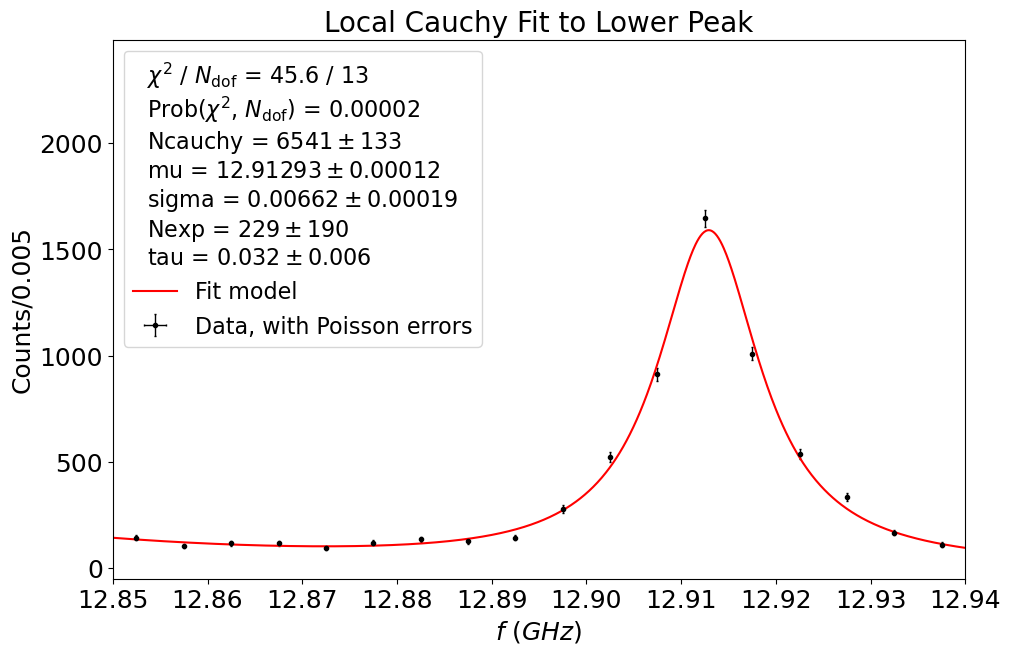

In [49]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

xx = np.linspace(lim1, lim2, 1000)
ax.plot(xx, fit_pdf2(xx, *mfit_cauchy.values[:]), '-r', label='Fit model')

ax.set_xlabel(r'$f$ $(GHz)$', fontsize=18)
ax.set_ylabel(f'Counts/{binwidth:.3f}', fontsize=18)
ax.set_title('Local Cauchy Fit to Lower Peak', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18)
ax.set_xlim(lim1, lim2)

# Adding fit results to plot:
chi2 = mfit_cauchy.fval 
Ndof = len(x[mask_cauchy]) - mfit_cauchy.nfit 
Prob = stats.chi2.sf(chi2, Ndof) 
print(Prob)

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.5f}",]
for p, v, e in zip(mfit_cauchy.parameters, mfit_cauchy.values[:], mfit_cauchy.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');

### 5.2.2

In [50]:
N1 = mfit1.values['Ngauss']
eN1 = mfit1.errors['Ngauss']
N2 = mfit2.values['Ngauss']
eN2 = mfit2.errors['Ngauss']
z_N = np.abs((N1 - N2)) / np.sqrt(eN1**2 + eN2**2)
p_N = 2*stats.norm.sf(z_N)
print(z_N, p_N)

1.6834472329091457 0.09228854618214873


### 5.2.3

#### Filtering

In [56]:
muE = np.mean(E)
sigmaE = np.std(E)
zE = np.abs(E-muE) / sigmaE
print(f'Mean of E: {muE:.4f}, Standard Deviation of E: {sigmaE:.4f}')
muD = np.mean(D)
sigmaD = np.std(D)
zD = np.abs(D-muD) / sigmaD
print(f'Mean of D: {muD:.4f}, Standard Deviation of D: {sigmaD:.4f}')
S = zE**2 + zD**2

Mean of E: 2.2243, Standard Deviation of E: 2.4015
Mean of D: 2.6766, Standard Deviation of D: 1.2831


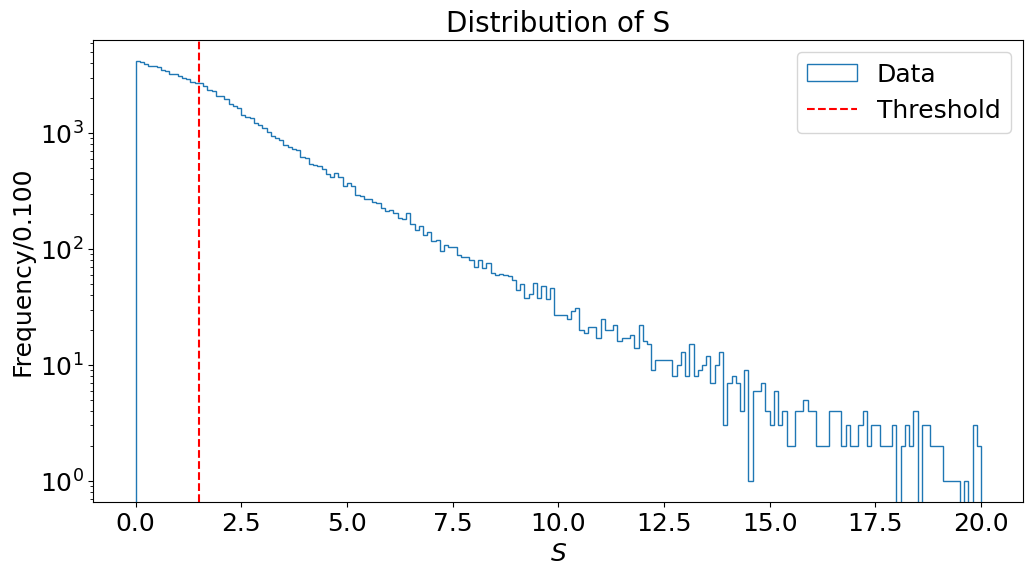

In [61]:
S = zE**2 + zD**2
xmin = 0
xmax = 20
Nbins = 200
binwidth = (xmax - xmin) / Nbins
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(S, bins=Nbins, range=(xmin, xmax), histtype='step', label='Data');
ax.axvline(1.5, color='r', linestyle='--', label='Threshold');
ax.set_xlabel(r'$S$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.3f}', fontsize=18)
ax.set_title('Distribution of S', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_yscale('log')
ax.legend(fontsize=18);

Number of outliers (S>1.5): 48414
0.4847799094805143


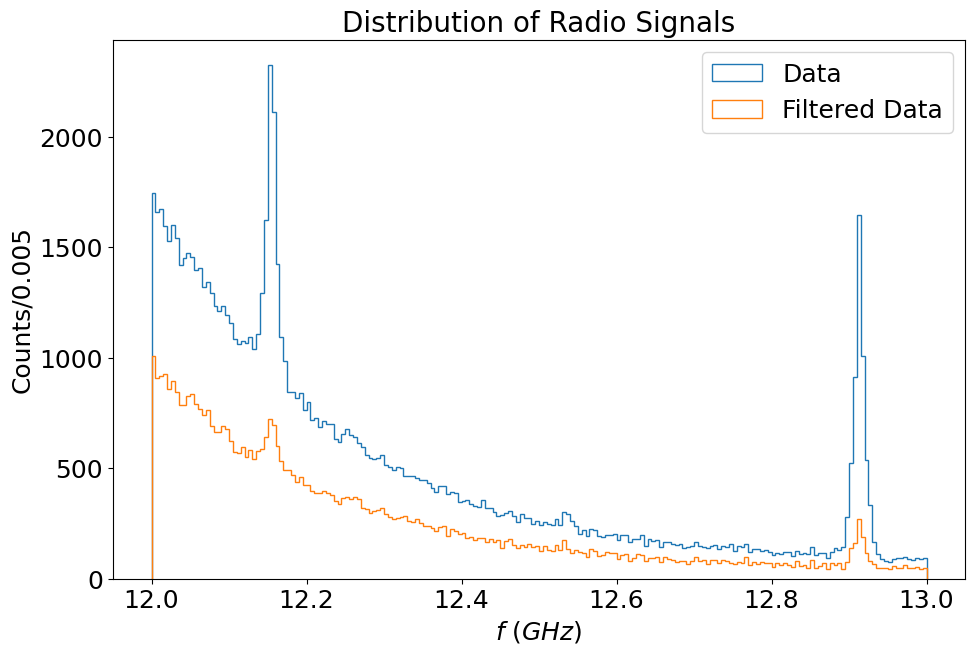

In [62]:
mask = (S > 1.5)
print(f'Number of outliers (S>1.5): {np.sum(mask)}')
freq_filtered = freq[~mask]
print(1-len(freq_filtered)/len(freq))
xmin = 12
xmax = 13
Nbins = 200
binwidth = (xmax - xmin) / Nbins

fig, ax = plt.subplots(figsize=(11, 7))
ax.hist(freq, bins=Nbins, range=(xmin, xmax), histtype='step', label='Data')
ax.hist(freq_filtered, bins=Nbins, range=(xmin, xmax), histtype='step', label='Filtered Data')

ax.set_xlabel(r'$f$ $(GHz)$', fontsize=18)
ax.set_ylabel(f'Counts/{binwidth:.3f}', fontsize=18)
ax.set_title('Distribution of Radio Signals', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18);

In [63]:
counts, bin_edges = np.histogram(freq_filtered, bins=Nbins, range=(xmin, xmax))
x = (bin_edges[1:] + bin_edges[:-1])/2
y = counts    
sy = np.sqrt(counts) 

In [64]:
mask1 = (x>12) & (x<12.4)
cfit1 = cost.LeastSquares(x[mask1], y[mask1], sy[mask1], fit_pdf)
mfit1 = Minuit(cfit1, x0=13, Ngauss=2500, mu=12.155, sigma=0.003, Nexp=4000, tau=0.27)
mfit1.limits['Ngauss'] = (0, 5000)
mfit1.limits['mu'] = (12.1, 12.2)
mfit1.limits['Nexp'] = (0, 10000)
mfit1.migrad();

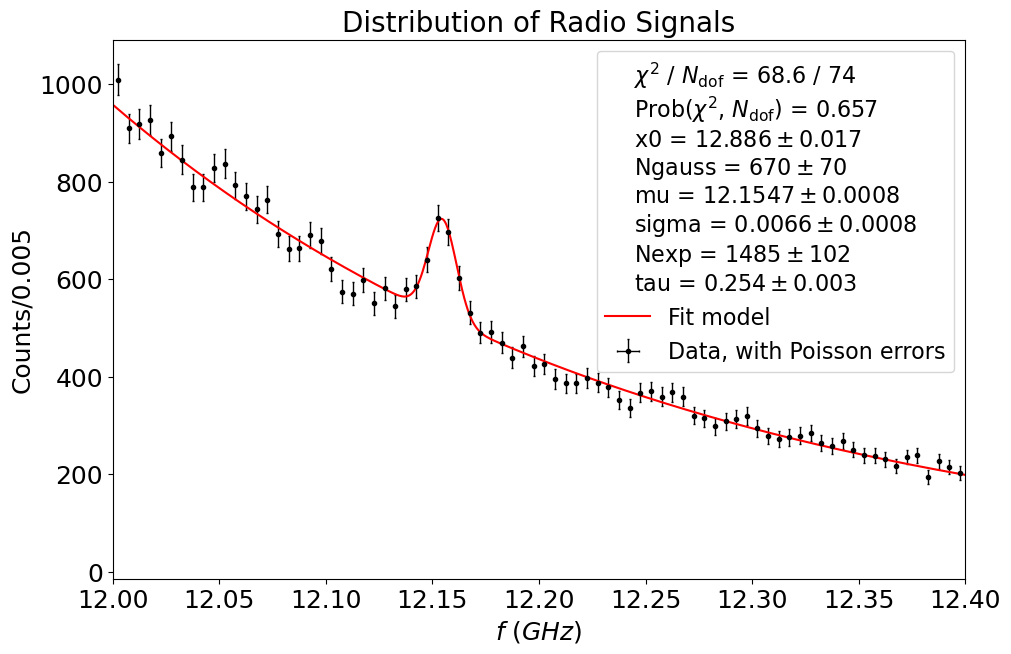

In [65]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

xx = np.linspace(12.0, 12.4, 1000)
ax.plot(xx, fit_pdf(xx, *mfit1.values[:]), '-r', label='Fit model')

ax.set_xlabel(r'$f$ $(GHz)$', fontsize=18)
ax.set_ylabel(f'Counts/{binwidth:.3f}', fontsize=18)
ax.set_title('Distribution of Radio Signals', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18)
ax.set_xlim(12, 12.4)

# Adding fit results to plot:
chi2 = mfit1.fval 
Ndof = len(x[mask1]) - mfit1.nfit 
Prob = stats.chi2.sf(chi2, Ndof) 

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]
for p, v, e in zip(mfit1.parameters, mfit1.values[:], mfit1.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');

In [66]:
mask2 = (x>12.6) & (x<13)
cfit2 = cost.LeastSquares(x[mask2], y[mask2], sy[mask2], fit_pdf)
mfit2 = Minuit(cfit2, x0=13, Ngauss=5000, mu=12.912, sigma=0.01, Nexp=4000, tau=0.27)
mfit2.migrad();

0.019470239950883168


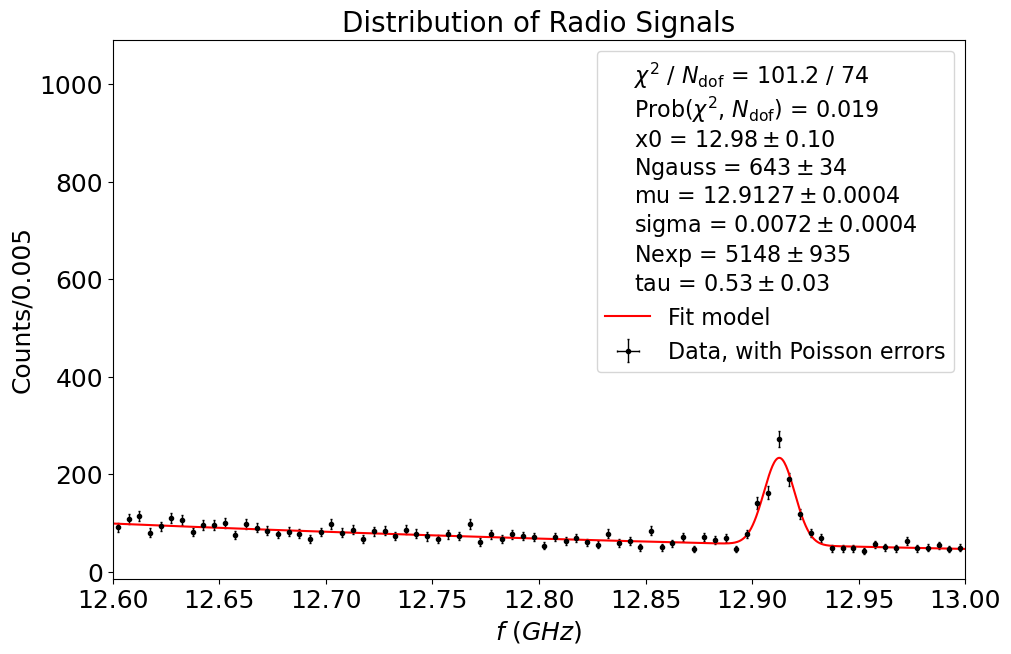

In [67]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

xx = np.linspace(12.6, 13, 1000)
ax.plot(xx, fit_pdf(xx, *mfit2.values[:]), '-r', label='Fit model')

ax.set_xlabel(r'$f$ $(GHz)$', fontsize=18)
ax.set_ylabel(f'Counts/{binwidth:.3f}', fontsize=18)
ax.set_title('Distribution of Radio Signals', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18)
ax.set_xlim(12.6, 13)

# Adding fit results to plot:
chi2 = mfit2.fval 
Ndof = len(x[mask2]) - mfit2.nfit 
Prob = stats.chi2.sf(chi2, Ndof) 
print(Prob)

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]
for p, v, e in zip(mfit2.parameters, mfit2.values[:], mfit2.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');

#### Cauchy fit

In [70]:
mask = (S > 3)
print(f'Number of outliers (S>2): {np.sum(mask)}')
freq_filtered = freq[~mask]
xmin = 12
xmax = 13
Nbins = 200
binwidth = (xmax - xmin) / Nbins
counts, bin_edges = np.histogram(freq_filtered, bins=Nbins, range=(xmin, xmax))
x = (bin_edges[1:] + bin_edges[:-1])/2
y = counts    
sy = np.sqrt(counts)

Number of outliers (S>2): 20677


In [71]:
def cauchy_cont(x, Ncauchy, mu, sigma, c):
    return Ncauchy * stats.cauchy.pdf(x, mu, sigma)*binwidth + c

In [72]:
lim1 = 12.895
lim2 = 12.932
mask2 = (x>lim1) & (x<lim2)
cfit2 = cost.LeastSquares(x[mask2], y[mask2], sy[mask2], cauchy_cont)
mfit2 = Minuit(cfit2, Ncauchy=5000, mu=12.912, sigma=0.01, c=0)
mfit2.limits['Ncauchy'] = (2000, 10000)
mfit2.limits['mu'] = (12.89, 12.93)
mfit2.limits['sigma'] = (0.005, 0.01)
mfit2.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.167 (χ²/ndof = 1.4)      │              Nfcn = 154              │
│ EDM = 2.55e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name    │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼─────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ Ncauchy │  3.14e3   │  0.26e3   │            │            │  2000   │  10000  │       │
│ 1 │ mu      │ 12.91276  │  0.00018  │            │            │  12.89  │  12.93  │       │
│ 2 │ sigma   │  6.1e-3   │  0.5e-3   │            │            │  0.005  │  0.01   │       │
│ 3 │ c       │    88     │    22     │            │            │         │         │       │
└───┴─────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────────┬─────────────────────────────────────────────────────┐
│         │      Ncauchy           mu        sigma            c │
├─────────┼─────────────────────────────────────────────────────┤
│ Ncauchy │     6.58e+04 -1.509382e-3 105.82993e-3       -5.4e3 │
│      mu │ -1.509382e-3     3.22e-08    -0.003e-6   133.967e-6 │
│   sigma │ 105.82993e-3    -0.003e-6     2.13e-07  -8.72808e-3 │
│       c │       -5.4e3   133.967e-6  -8.72808e-3          488 │
└─────────┴─────────────────────────────────────────────────────┘

0.24401983211897835


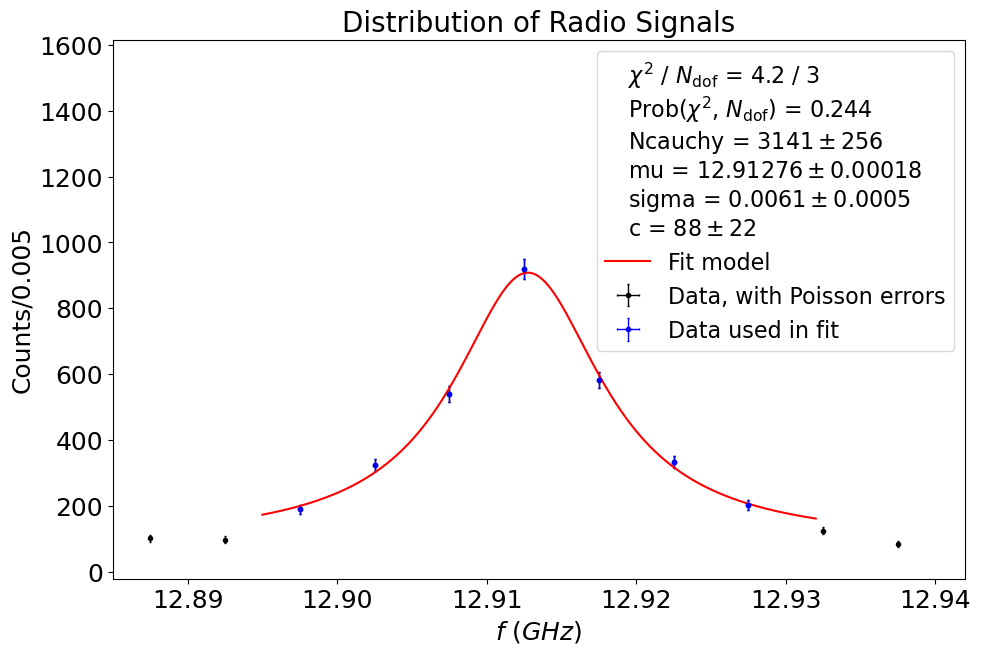

In [73]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)
ax.errorbar(x[mask2], y[mask2], yerr=sy[mask2], xerr=0.0, label='Data used in fit', fmt='.b',  ecolor='b', elinewidth=1, capsize=1, capthick=1)
# ax.axhline(fit_pdf2(lim1, *mfit2.values[:]), color='r', linestyle='--', label='Fit at lower limit')
xx = np.linspace(lim1, lim2, 1000)
ax.plot(xx, cauchy_cont(xx, *mfit2.values[:]), '-r', label='Fit model')

ax.set_xlabel(r'$f$ $(GHz)$', fontsize=18)
ax.set_ylabel(f'Counts/{binwidth:.3f}', fontsize=18)
ax.set_title('Distribution of Radio Signals', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18)
ax.set_xlim(lim1-0.01, lim2+0.01)

# Adding fit results to plot:
chi2 = mfit2.fval 
Ndof = len(x[mask2]) - mfit2.nfit 
Prob = stats.chi2.sf(chi2, Ndof) 
print(Prob)

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]
for p, v, e in zip(mfit2.parameters, mfit2.values[:], mfit2.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');

### 5.2.4

In [87]:
xmin = 12
xmax = 13
Nbins = 200
binwidth = (xmax - xmin) / Nbins
counts, bin_edges = np.histogram(freq, bins=Nbins, range=(xmin, xmax))
x = (bin_edges[1:] + bin_edges[:-1])/2
y = counts
sy = np.sqrt(counts)

mask_mid = (x>12.4) & (x<12.7)

cfit_mid = cost.LeastSquares(x[mask_mid], y[mask_mid], sy[mask_mid], fit_pdf)
mfit_mid = Minuit(cfit_mid, x0=13, Ngauss=205, mu=12.53, sigma=0.01, Nexp=2500, tau=0.25)
mfit_mid.limits['Ngauss'] = (0, 2000)
mfit_mid.limits['mu'] = (12.48, 12.58)
mfit_mid.limits['Nexp'] = (0, 5000)
mfit_mid.limits['sigma'] = (0, 0.05)
mfit_mid.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 39.96 (χ²/ndof = 0.7)      │              Nfcn = 335              │
│ EDM = 7.21e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name   │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ x0     │   13.05   │   0.04    │            │            │         │         │       │
│ 1 │ Ngauss │    180    │    40     │            │            │    0    │  2000   │       │
│ 2 │ mu     │  12.5357  │  0.0013   │            │            │  12.48  │  12.58  │       │
│ 3 │ sigma  │  0.0053   │  0.0015   │            │            │    0    │  0.05   │       │
│ 4 │ Nexp   │   3.3e3   │   0.4e3   │            │            │    0    │  5000   │       │
│ 5 │ tau    │   0.331   │   0.009   │            │            │         │         │       │
└───┴────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────────┬───────────────────────────────────────────────────────────────────┐
│        │         x0     Ngauss         mu      sigma       Nexp        tau │
├────────┼───────────────────────────────────────────────────────────────────┤
│     x0 │    0.00144    -0.0298    -0.3e-6    -0.7e-6   -11.5618    0.11e-3 │
│ Ngauss │    -0.0298   1.79e+03   169.7e-6 38.0318e-3     -0.3e3   -8.18e-3 │
│     mu │    -0.3e-6   169.7e-6   1.72e-06     0.1e-6 -2.7512e-3    -0.2e-6 │
│  sigma │    -0.7e-6 38.0318e-3     0.1e-6   2.25e-06 -7.0239e-3    -0.2e-6 │
│   Nexp │   -11.5618     -0.3e3 -2.7512e-3 -7.0239e-3   1.42e+05    1.04710 │
│    tau │    0.11e-3   -8.18e-3    -0.2e-6    -0.2e-6    1.04710   8.27e-05 │
└────────┴───────────────────────────────────────────────────────────────────┘

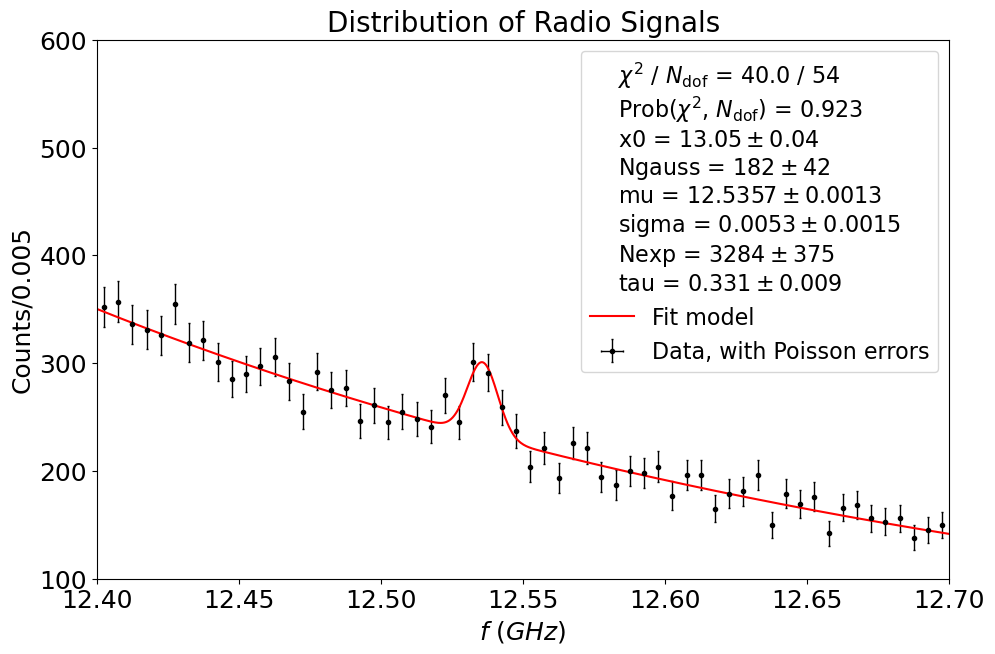

In [88]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.errorbar(x, y, yerr=sy, xerr=0.0, label='Data, with Poisson errors', fmt='.k',  ecolor='k', elinewidth=1, capsize=1, capthick=1)

xx = np.linspace(12.4, 12.7, 1000)
ax.plot(xx, fit_pdf(xx, *mfit_mid.values[:]), '-r', label='Fit model')

ax.set_xlabel(r'$f$ $(GHz)$', fontsize=18)
ax.set_ylabel(f'Counts/{binwidth:.3f}', fontsize=18)
ax.set_title('Distribution of Radio Signals', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18)
ax.set_xlim(12.4, 12.7)
ax.set_ylim(100, 600);

# Adding fit results to plot:
chi2 = mfit_mid.fval 
Ndof = len(x[mask_mid]) - mfit_mid.nfit 
Prob = stats.chi2.sf(chi2, Ndof) 

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.3f}",]
for p, v, e in zip(mfit_mid.parameters, mfit_mid.values[:], mfit_mid.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');